<a href="https://colab.research.google.com/github/mdaminu2002-sketch/bank_fraud/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# MNIST dataset — no Kaggle needed, PyTorch downloads it automatically
transform = transforms.Compose([
    transforms.ToTensor()  # converts to [0,1] range, no normalization needed for VAE
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

# Peek at one batch
images, labels = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")  # [128, 1, 28, 28]
print(f"Label batch shape: {labels.shape}")  # [128]

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 42.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


Train samples: 60000
Test samples:  10000
Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])


In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # --- ENCODER ---
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        # Two separate heads — one for mu, one for log_var
        self.mu      = nn.Linear(hidden_dim, latent_dim)
        self.log_var = nn.Linear(hidden_dim, latent_dim)

        # --- DECODER ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # output must be [0,1] to match pixel values
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.log_var(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)  # convert log_var to std
        eps = torch.randn_like(std)      # random noise, same shape as std
        return mu + std * eps            # z = mu + std * epsilon

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        # Flatten image: [batch, 1, 28, 28] → [batch, 784]
        x = x.view(x.size(0), -1)

        # Encode
        mu, log_var = self.encode(x)

        # Sample z using reparameterization trick
        z = self.reparameterize(mu, log_var)

        # Decode
        reconstructed = self.decode(z)

        return reconstructed, mu, log_var


# Initialize model
model = VAE(input_dim=784, hidden_dim=400, latent_dim=20).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (mu): Linear(in_features=400, out_features=20, bias=True)
  (log_var): Linear(in_features=400, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Total parameters: 652,824


In [4]:
def vae_loss(reconstructed, original, mu, log_var):
    # Flatten original: [batch, 1, 28, 28] → [batch, 784]
    original = original.view(original.size(0), -1)

    # --- RECONSTRUCTION LOSS ---
    # How similar is the output to the input, pixel by pixel
    # reduction='sum' adds up all pixel errors across the batch
    reconstruction_loss = F.binary_cross_entropy(
        reconstructed, original, reduction='sum'
    )

    # --- KL DIVERGENCE ---
    # How close is our learned distribution to standard normal N(0,1)
    # Formula: -0.5 * sum(1 + log_var - mu² - exp(log_var))
    kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return reconstruction_loss + kl_divergence

In [5]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, _ in train_loader:  # note: _ means we ignore labels
        images = images.to(device)

        # Forward pass
        reconstructed, mu, log_var = model(images)

        # Compute loss
        loss = vae_loss(reconstructed, images, mu, log_var)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_dataset)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

print("Training complete!")

Epoch 1/10 | Loss: 163.9492
Epoch 2/10 | Loss: 121.3477
Epoch 3/10 | Loss: 114.4504
Epoch 4/10 | Loss: 111.5334
Epoch 5/10 | Loss: 109.8100
Epoch 6/10 | Loss: 108.6798
Epoch 7/10 | Loss: 107.8128
Epoch 8/10 | Loss: 107.1862
Epoch 9/10 | Loss: 106.7078
Epoch 10/10 | Loss: 106.2767
Training complete!


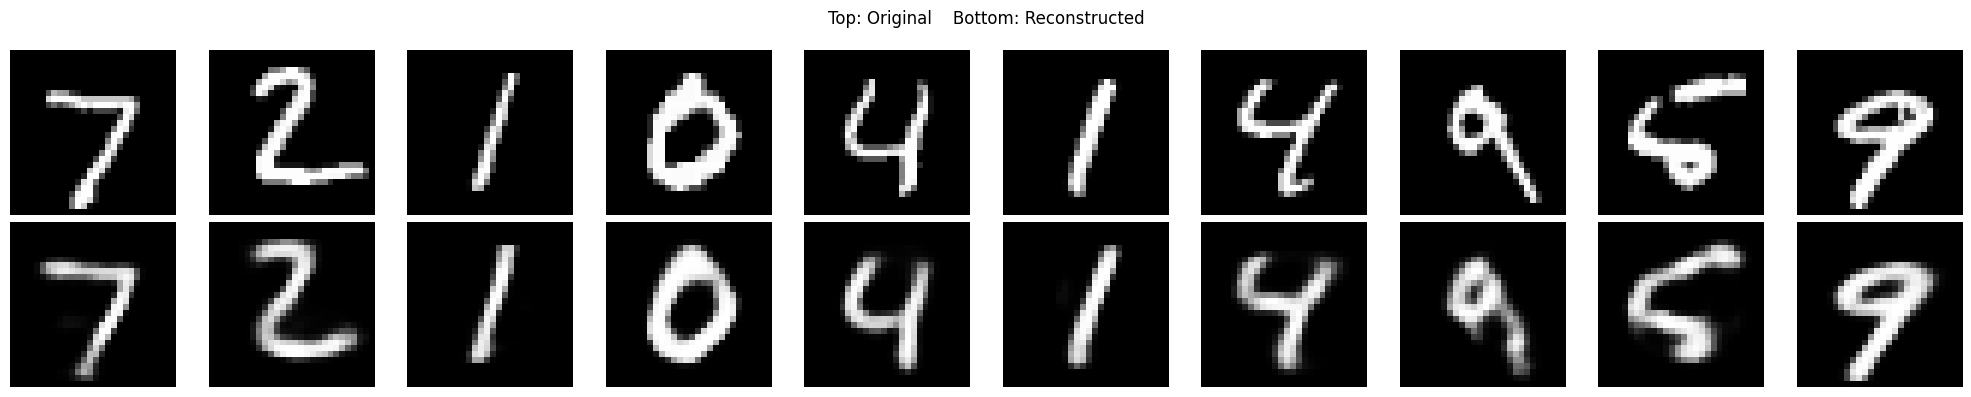

In [6]:
model.eval()

# Get one batch from test set
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    reconstructed, mu, log_var = model(test_images)

# Reshape back to image format
original      = test_images.cpu().view(-1, 28, 28)
reconstructed = reconstructed.cpu().view(-1, 28, 28)

# Plot first 10 originals vs reconstructions
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
fig.suptitle("Top: Original    Bottom: Reconstructed", fontsize=12)

for i in range(10):
    # Original
    axes[0, i].imshow(original[i], cmap='gray')
    axes[0, i].axis('off')

    # Reconstructed
    axes[1, i].imshow(reconstructed[i], cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

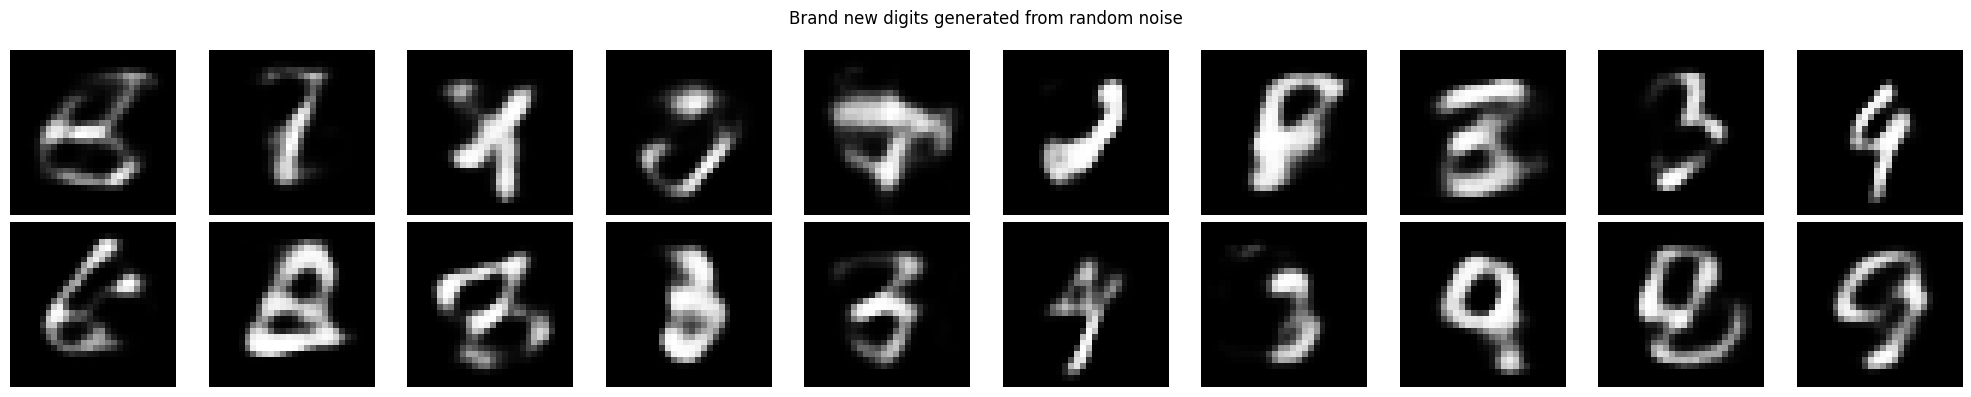

In [7]:
model.eval()

with torch.no_grad():
    # Sample random z vectors from standard normal N(0,1)
    # This is where the magic happens — no input image needed
    z = torch.randn(20, 20).to(device)  # 20 random points in latent space
    generated = model.decode(z).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
fig.suptitle("Brand new digits generated from random noise", fontsize=12)

for i in range(20):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(generated[i], cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

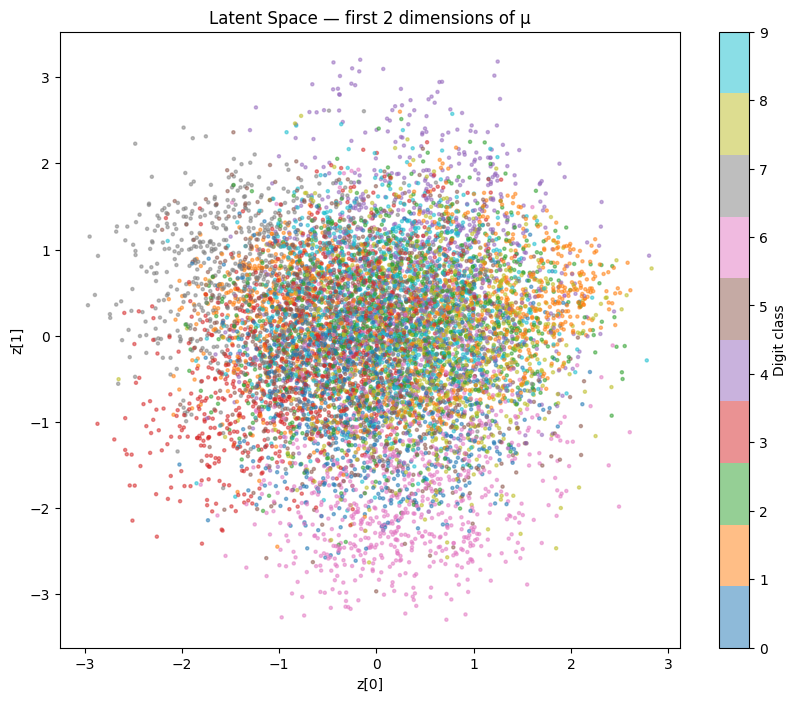

In [8]:
# Encode ALL test images and plot their mu values in 2D
# We'll use only the first 2 dimensions of the 20-dim latent space

model.eval()
all_mu, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu, _ = model.encode(images.view(images.size(0), -1))
        all_mu.append(mu.cpu())
        all_labels.append(labels)

all_mu     = torch.cat(all_mu, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

# Plot first 2 dimensions
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    all_mu[:, 0], all_mu[:, 1],
    c=all_labels, cmap='tab10',
    alpha=0.5, s=5
)
plt.colorbar(scatter, label='Digit class')
plt.title('Latent Space — first 2 dimensions of μ')
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.show()